## ======================================================================
## 🧠 Hopify SaaS: Monthly Active Customers vs 3-Month Rolling Average
## ======================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)


## ==================================================
## 📥 Load Data
## ==================================================

In [4]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "17_hopify_3mo_rolling_avg_active_cust_over_time.csv"
)

df = pd.read_csv(file_path)

## ================================
## 🧼 Clean & Prepare Columns
## ================================

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("%", "percent")
    .str.lower()
)

# Parse dates and sort
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')

# Extract fiscal quarter
df['fiscal_quarter'] = df['month'].dt.to_period('Q').astype(str)
df['fiscal_quarter'] = pd.Categorical(df['fiscal_quarter'], categories=sorted(df['fiscal_quarter'].unique()), ordered=True)

## ==================================================
## Plot
## ==================================================

/var/folders/z4/bhxvrvmn0n30jr8zdx9wy1x80000gn/T/ipykernel_39733/2769573016.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


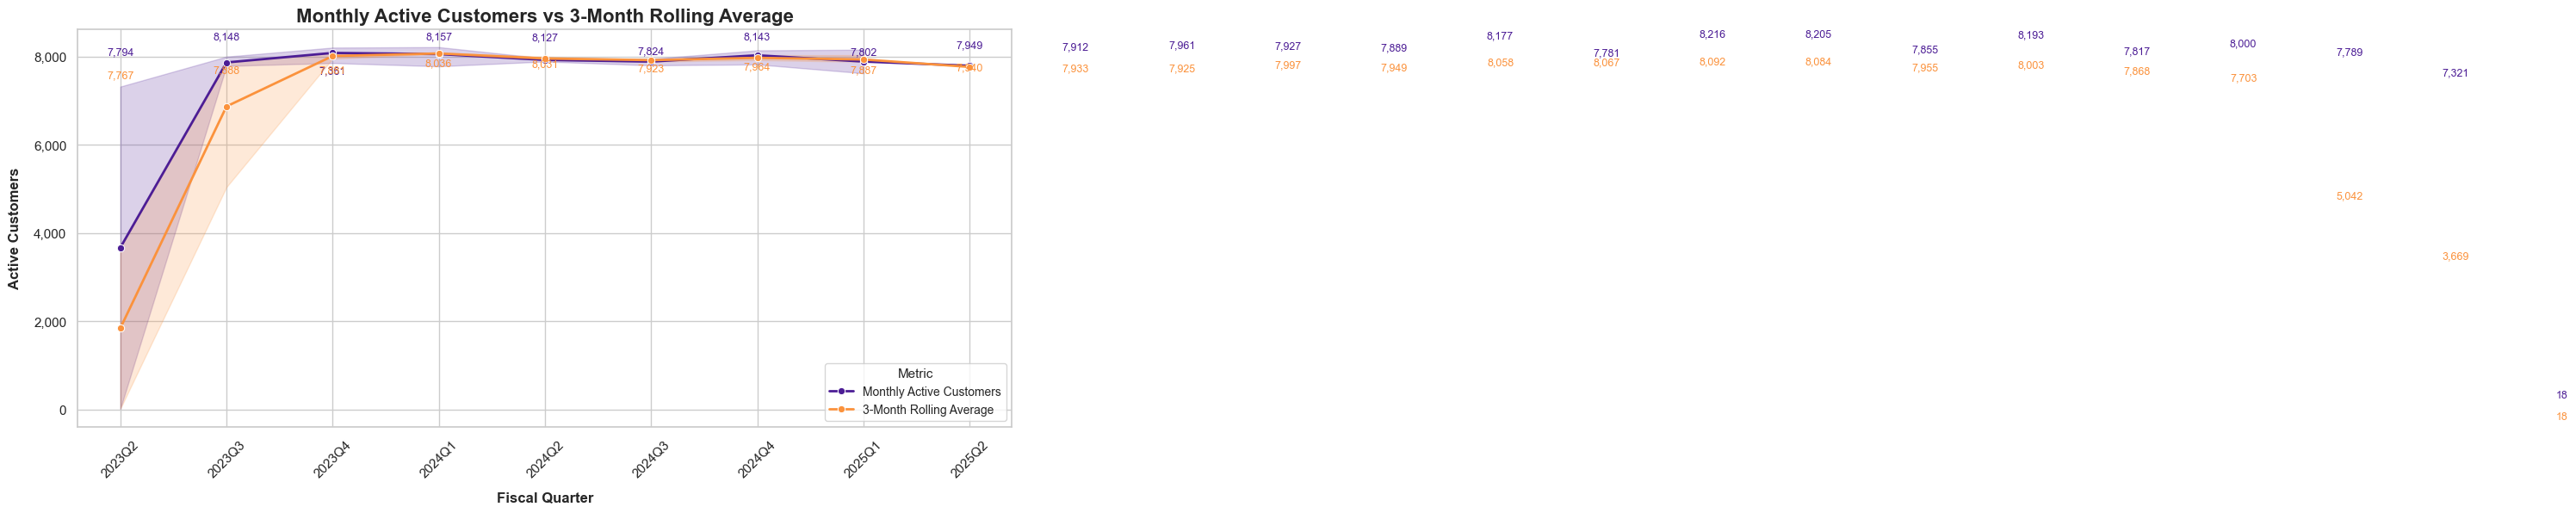

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Line plots
sns.lineplot(
    data=df,
    x='fiscal_quarter',
    y='active_customers',
    label='Monthly Active Customers',
    marker='o',
    linewidth=2,
    color='#4c1d95'
)

sns.lineplot(
    data=df,
    x='fiscal_quarter',
    y='rolling_avg_3mo',
    label='3-Month Rolling Average',
    marker='o',
    linewidth=2,
    color='#fb923c'
)

# Add annotated value labels above/below each point
for i, row in df.iterrows():
    plt.text(
        i,
        row['active_customers'] + 250,
        f"{int(row['active_customers']):,}",
        ha='center',
        fontsize=9,
        color='#4c1d95'
    )
    plt.text(
        i,
        row['rolling_avg_3mo'] - 250,
        f"{int(row['rolling_avg_3mo']):,}",
        ha='center',
        fontsize=9,
        color='#fb923c'
    )

# ================================
# 🎨 Format Chart
# ================================

plt.title("Monthly Active Customers vs 3-Month Rolling Average", fontsize=16, fontweight='bold')
plt.xlabel("Fiscal Quarter", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Active Customers", fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.legend(title="Metric", title_fontsize=11, fontsize=10)
plt.tight_layout()

# ================================
# 💾 Save & Show
# ================================

In [7]:
output_path = os.path.join(BASE_PATH, "05_visuals", "hopify_active_cust_vs_rolling_avg.png")
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>